Seaborn의 iris 데이터를 사용해 아래 요구사항을 모두 충족하는 시각화를 만드세요.

**지시사항:**

##1. 꽃 종류(species) 별로 sepal_length와 sepal_width의 관계를 scatter plot으로 표현하세요.
	색상은 species에 따라 다르게 표현
	seaborn의 scatterplot 사용
##2. sepal_length의 분포를 Histogram + KDE를 함께 나타내는 distplot 또는 displot(seaborn 버전 따라 선택)으로 시각화하세요.
	bins 개수는 최소 20 이상 설정
##3. 네 가지 특징(sepal_length, sepal_width, petal_length, petal_width) 간의 상관관계를 heatmap으로 시각화하세요.
	annot=True 옵션을 사용해 수치를 표시할 것
	cmap은 적절한 연속형 팔레트 사용 (예: "Blues", "coolwarm")

위 세 그래프는 서브플롯 3개로 구성된 하나의 figure로 나타내세요.

[출력 형태 예시]
Fig: scatter plot / distplot(or hist+kde) / heatmap
모든 subplot에 제목 포함

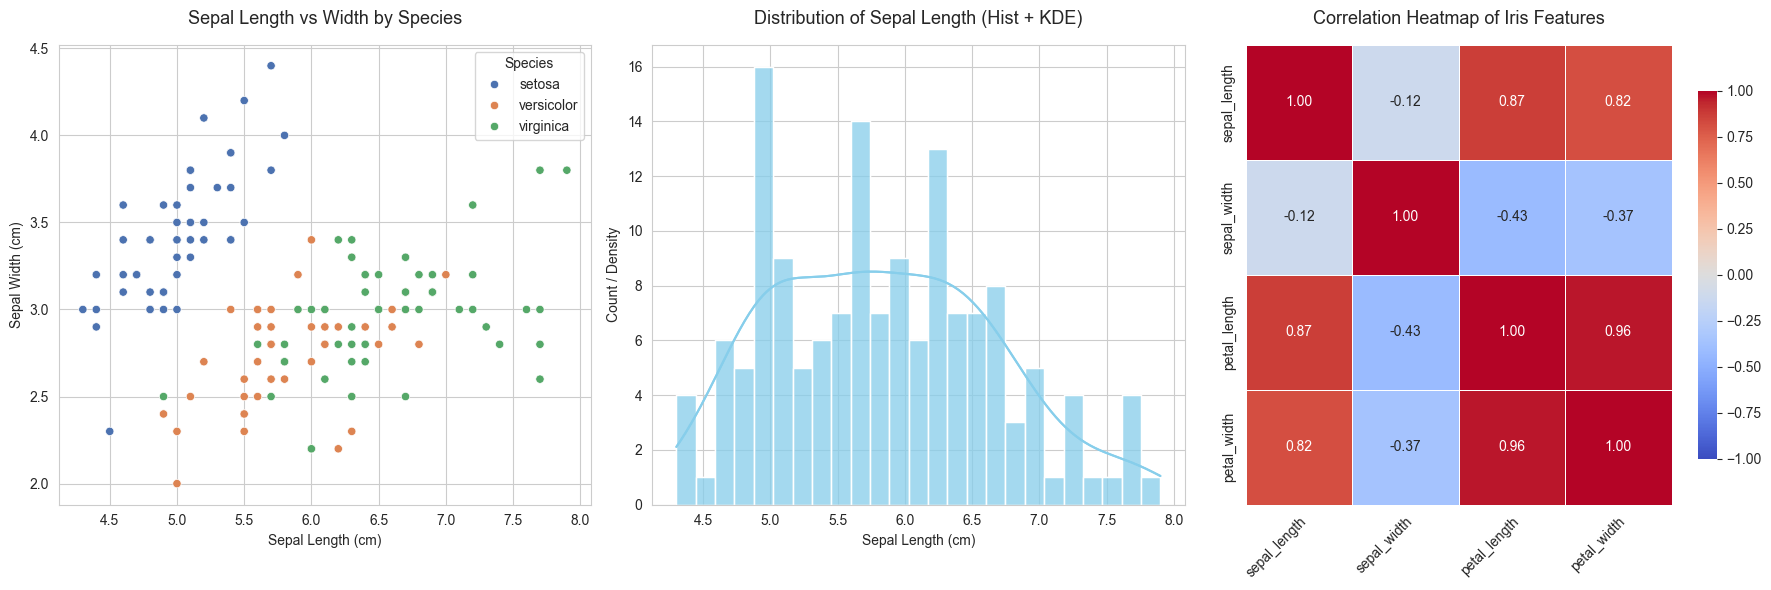

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

iris = sns.load_dataset('iris')
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue='species',      # 꽃 종류별 색상 구분
    palette='deep',     # 세련된 색상 팔레트
    ax=axes[0]          # 첫 번째 서브플롯에 그리기
)

axes[0].set_title("Sepal Length vs Width by Species", fontsize=13, pad=15)
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].legend(title="Species", loc='upper right', fontsize=10)
# (1) 서브플롯
sns.histplot(
    data=iris,
    x='sepal_length',
    bins=25,            # bins 개수 20 이상 설정 (요구사항)
    kde=True,           # KDE(커널 밀도 추정) 곡선 추가
    color='skyblue',    # 막대 색상
    edgecolor='w',      # 막대 테두리 흰색
    ax=axes[1]          # 두 번째 서브플롯에 그리기
)

axes[0].set_title("Sepal Length vs Width by Species", fontsize=13, pad=15)
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].legend(title="Species", loc='upper right', fontsize=10)

# (2) 서브플롯
sns.histplot(
    data=iris,
    x='sepal_length',
    bins=25,            # bins 개수 20 이상 설정 (요구사항)
    kde=True,           # KDE(커널 밀도 추정) 곡선 추가
    color='skyblue',    # 막대 색상
    edgecolor='w',      # 막대 테두리 흰색
    ax=axes[1]          # 두 번째 서브플롯에 그리기
)

axes[1].set_title("Distribution of Sepal Length (Hist + KDE)", fontsize=13, pad=15)
axes[1].set_xlabel("Sepal Length (cm)")
axes[1].set_ylabel("Count / Density")

# (3) 서브플롯
numeric_iris = iris.select_dtypes(include='number')
corr_matrix = numeric_iris.corr()

sns.heatmap(
    corr_matrix,
    annot=True,         # 수치 표시 (요구사항)
    fmt=".2f",          # 소수점 둘째 자리까지 표시
    cmap='coolwarm',    # 연속형 팔레트 (요구사항: Blue-Red 계열)
    vmin=-1, vmax=1,    # 상관계수 범위 고정 (-1 ~ 1)
    linewidths=.5,      # 셀 사이 간격
    cbar_kws={"shrink": .8}, # 컬러바 크기 조절
    ax=axes[2]          # 세 번째 서브플롯에 그리기
)

axes[2].set_title("Correlation Heatmap of Iris Features", fontsize=13, pad=15)
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")



plt.tight_layout() 
plt.show()
